In [373]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [374]:
#Load the dataset
df = pd.read_csv('data.csv')
df

,transaction_id,customer_id,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,T0000001,C007297,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,0
1,T0000002,C001640,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,0
2,T0000003,C018025,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,0
3,T0000004,C016050,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,0
4,T0000005,C014629,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,T0099996,C025888,46-55,Other,Atlanta,New,P1702,Sports,462.86,25.0,347.14,2.0,694.28,Gift Card,28/11/2025,0.0,0,1
99996,T0099997,C028276,56+,Male,Houston,Returning,P3742,Beauty,87.86,15.0,74.68,2.0,149.36,Credit Card,26/11/2025,0.0,0,0
99997,T0099998,C025960,46-55,Other,Phoenix,VIP,P2100,Electronics,1930.61,40.0,1158.37,1.0,1158.37,Credit Card,30/11/2025,0.0,1,0
99998,T0099999,C005656,46-55,Other,Miami,New,P7444,Beauty,156.74,25.0,117.56,1.0,117.56,Gift Card,30/11/2025,6.0,1,0


In [375]:
df.shape

(100000, 18)

In [376]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  object 
 1   customer_id       100000 non-null  object 
 2   age_group         99966 non-null   object 
 3   gender            99966 non-null   object 
 4   city              99944 non-null   object 
 5   customer_segment  99944 non-null   object 
 6   product_id        99953 non-null   object 
 7   product_category  99966 non-null   object 
 8   original_price    99931 non-null   float64
 9   discount_pct      99931 non-null   float64
 10  final_price       99931 non-null   float64
 11  quantity          99966 non-null   float64
 12  purchase_amount   99966 non-null   float64
 13  payment_method    99956 non-null   object 
 14  purchase_date     99956 non-null   object 
 15  purchase_hour     99990 non-null   float64
 16  is_weekend        100

In [377]:
# # df.columns
# print(str(list(df.columns)))


# x=list(df.columns)
# for column in df.columns:
#     print(column,df[column].dtype, df[column].count())

In [378]:
#remove/drop columns
# df.drop(columns=[], inplace=True)
df2=df.drop(columns=['transaction_id','customer_id'])
df2.columns

Index(['age_group', 'gender', 'city', 'customer_segment', 'product_id',
       'product_category', 'original_price', 'discount_pct', 'final_price',
       'quantity', 'purchase_amount', 'payment_method', 'purchase_date',
       'purchase_hour', 'is_weekend', 'is_black_friday'],
      dtype='object')

In [379]:
#select columns
df3=df2[['age_group', 'gender', 'city']]
df3.columns

Index(['age_group', 'gender', 'city'], dtype='object')

In [380]:
#check top 5 rows
df2.head()


# df2.tail() #last 5 rows

,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,is_weekend,is_black_friday
0,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,0
1,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,0
2,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,0
3,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,0
4,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,0


In [381]:
df.describe()

,original_price,discount_pct,final_price,quantity,purchase_amount,purchase_hour,is_weekend,is_black_friday
count,99931.000000,99931.000000,99931.000000,99966.000000,99966.000000,99990.000000,100000.000000,100000.000000
mean,330.292829,26.630925,242.228207,1.447292,351.259131,11.482198,0.248110,0.126330
std,444.360594,12.248528,332.710547,0.815727,589.906720,6.912711,0.431918,0.332223
min,5.000000,5.000000,2.070000,1.000000,2.220000,0.000000,0.000000,0.000000
25%,88.100000,20.000000,62.930000,1.000000,75.750000,5.000000,0.000000,0.000000
50%,180.220000,25.000000,129.490000,1.000000,161.150000,11.000000,0.000000,0.000000
75%,333.735000,35.000000,247.580000,2.000000,358.707500,17.000000,0.000000,0.000000
max,2499.890000,60.000000,2374.900000,5.000000,11441.800000,23.000000,1.000000,1.000000


# Preprocessing
 - shortlist columns (keep columns that will be used in the analysis)
 - use approapriate data types
 - use appropriate field names
 - handle missing values - remove records with missing values/replace them with mean
 - remove/eliminate dupplicate values
 - encode data in approapriate formats
 - handle outliers


In [382]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age_group         99966 non-null   object 
 1   gender            99966 non-null   object 
 2   city              99944 non-null   object 
 3   customer_segment  99944 non-null   object 
 4   product_id        99953 non-null   object 
 5   product_category  99966 non-null   object 
 6   original_price    99931 non-null   float64
 7   discount_pct      99931 non-null   float64
 8   final_price       99931 non-null   float64
 9   quantity          99966 non-null   float64
 10  purchase_amount   99966 non-null   float64
 11  payment_method    99956 non-null   object 
 12  purchase_date     99956 non-null   object 
 13  purchase_hour     99990 non-null   float64
 14  is_weekend        100000 non-null  int64  
 15  is_black_friday   100000 non-null  int64  
dtypes: float64(6), int64(

In [383]:
#data type manipulation
df2['is_weekend'].astype('bool') #int float bool
df2['is_black_friday'] = df2['is_weekend'].astype('bool')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age_group         99966 non-null   object 
 1   gender            99966 non-null   object 
 2   city              99944 non-null   object 
 3   customer_segment  99944 non-null   object 
 4   product_id        99953 non-null   object 
 5   product_category  99966 non-null   object 
 6   original_price    99931 non-null   float64
 7   discount_pct      99931 non-null   float64
 8   final_price       99931 non-null   float64
 9   quantity          99966 non-null   float64
 10  purchase_amount   99966 non-null   float64
 11  payment_method    99956 non-null   object 
 12  purchase_date     99956 non-null   object 
 13  purchase_hour     99990 non-null   float64
 14  is_weekend        100000 non-null  int64  
 15  is_black_friday   100000 non-null  bool   
dtypes: bool(1), float64(6

In [384]:
#rename columns
df2.rename(columns={'is_black_friday': 'black_friday', 'is_weekend': 'weekend'}, inplace=True)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age_group         99966 non-null   object 
 1   gender            99966 non-null   object 
 2   city              99944 non-null   object 
 3   customer_segment  99944 non-null   object 
 4   product_id        99953 non-null   object 
 5   product_category  99966 non-null   object 
 6   original_price    99931 non-null   float64
 7   discount_pct      99931 non-null   float64
 8   final_price       99931 non-null   float64
 9   quantity          99966 non-null   float64
 10  purchase_amount   99966 non-null   float64
 11  payment_method    99956 non-null   object 
 12  purchase_date     99956 non-null   object 
 13  purchase_hour     99990 non-null   float64
 14  weekend           100000 non-null  int64  
 15  black_friday      100000 non-null  bool   
dtypes: bool(1), float64(6

In [385]:
#handling missing values
df2.isnull().sum()

age_group           34
gender              34
city                56
customer_segment    56
product_id          47
product_category    34
original_price      69
discount_pct        69
final_price         69
quantity            34
purchase_amount     34
payment_method      44
purchase_date       44
purchase_hour       10
weekend              0
black_friday         0
dtype: int64

In [386]:
df.shape

(100000, 18)

In [387]:
dfx=df2['age_group'].dropna() #drop missing values from a specific column
dfx.shape

(99966,)

In [388]:
#drop missing values
df4=df2.dropna() #drop rows with missing values
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99918 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_group         99918 non-null  object 
 1   gender            99918 non-null  object 
 2   city              99918 non-null  object 
 3   customer_segment  99918 non-null  object 
 4   product_id        99918 non-null  object 
 5   product_category  99918 non-null  object 
 6   original_price    99918 non-null  float64
 7   discount_pct      99918 non-null  float64
 8   final_price       99918 non-null  float64
 9   quantity          99918 non-null  float64
 10  purchase_amount   99918 non-null  float64
 11  payment_method    99918 non-null  object 
 12  purchase_date     99918 non-null  object 
 13  purchase_hour     99918 non-null  float64
 14  weekend           99918 non-null  int64  
 15  black_friday      99918 non-null  bool   
dtypes: bool(1), float64(6), int64(1), object(8)
m

In [389]:
df2['age_group'].unique()

array(['26-35', '56+', '18-25', '46-55', '36-45', nan], dtype=object)

In [390]:
dfz=df2['age_group'].fillna('Rather not say')
dfz.unique()

array(['26-35', '56+', '18-25', '46-55', '36-45', 'Rather not say'],
      dtype=object)

In [391]:
average=df2['purchase_amount'].mean()
dfy=df2['purchase_amount'].fillna(average)
dfy.isnull().sum()

np.int64(0)

In [392]:
#detectign duplicates
df4.duplicated().sum()

# df4.drop_duplicates(inplace=True)

df4.info()


<class 'pandas.core.frame.DataFrame'>
Index: 99918 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_group         99918 non-null  object 
 1   gender            99918 non-null  object 
 2   city              99918 non-null  object 
 3   customer_segment  99918 non-null  object 
 4   product_id        99918 non-null  object 
 5   product_category  99918 non-null  object 
 6   original_price    99918 non-null  float64
 7   discount_pct      99918 non-null  float64
 8   final_price       99918 non-null  float64
 9   quantity          99918 non-null  float64
 10  purchase_amount   99918 non-null  float64
 11  payment_method    99918 non-null  object 
 12  purchase_date     99918 non-null  object 
 13  purchase_hour     99918 non-null  float64
 14  weekend           99918 non-null  int64  
 15  black_friday      99918 non-null  bool   
dtypes: bool(1), float64(6), int64(1), object(8)
m

In [393]:
df4.head()

,age_group,gender,city,customer_segment,product_id,product_category,original_price,discount_pct,final_price,quantity,purchase_amount,payment_method,purchase_date,purchase_hour,weekend,black_friday
0,26-35,Male,San Francisco,Loyal,P2713,Footwear,153.73,35.0,99.92,1.0,99.92,Credit Card,01/12/2025,0.0,0,False
1,56+,Other,Dallas,Returning,P7219,Beauty,230.05,40.0,138.03,1.0,138.03,PayPal,24/11/2025,5.0,0,False
2,26-35,Male,Phoenix,New,P5521,Groceries,174.67,25.0,131.00,1.0,131.00,Credit Card,24/11/2025,14.0,0,False
3,18-25,Other,Miami,VIP,P3003,Sports,399.61,40.0,239.77,1.0,239.77,Credit Card,30/11/2025,23.0,1,True
4,46-55,Male,Los Angeles,Loyal,P4633,Footwear,120.87,30.0,84.61,2.0,169.22,Debit Card,25/11/2025,2.0,0,False


In [394]:
df4['gender'].value_counts()

gender
Female    33430
Male      33371
Other     33117
Name: count, dtype: int64

In [395]:
#encoding categorical variables

from sklearn.preprocessing import LabelEncoder

# gender_le=LabelEncoder()
# df4['gender']=gender_le.fit_transform(df4['gender'])
# df4.head()

# # age_group_le=LabelEncoder()
# # df4['age_group']=age_group_le.fit_transform(df4['age_group'])
# # df4.head()

# # map={
# #     'Male':0,
# #     'Female':1,
# #     'Other':2
# # }

# # df4['gender'].replace(map, inplace=True)
# # df4.head()

# x=gender_le.classes_
# gender_le.inverse_transform(x)
# mapping = dict(zip(gender_le.classes_, range(len(gender_le.classes_))))
# mapping




<Axes: >

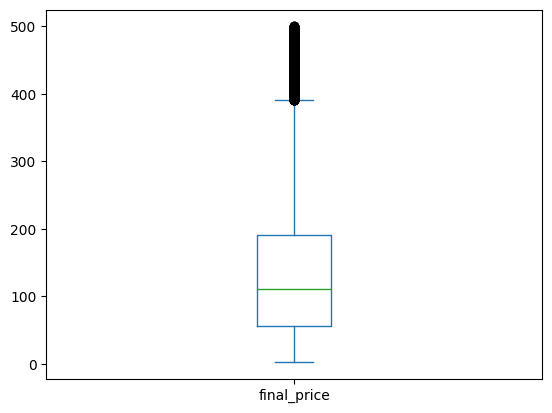

In [396]:
# df4['final_price'].plot(kind='box')
# df5=df4[df4['final_price']<500]
df5=df4.query('final_price<500')
df5['final_price'].plot(kind='box')



<Axes: >

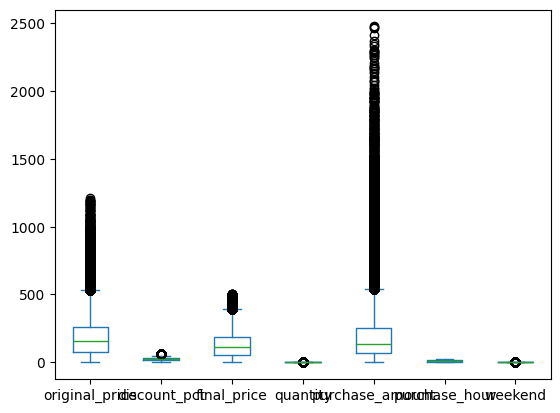

In [397]:
df5.plot(kind='box')

In [398]:
df5.count()

age_group           87933
gender              87933
city                87933
customer_segment    87933
product_id          87933
product_category    87933
original_price      87933
discount_pct        87933
final_price         87933
quantity            87933
purchase_amount     87933
payment_method      87933
purchase_date       87933
purchase_hour       87933
weekend             87933
black_friday        87933
dtype: int64

In [399]:
df5.to_csv('cleaned_data.csv', index=False)